# Ensemble Methods: The Power of Combining Models

## Introduction

You've now built individual models for both regression and classification — and they work pretty well! But what if you could combine multiple models to get something even better? That's the core idea behind **ensemble methods**, and they're responsible for winning the majority of machine learning competitions.

Think of it this way: if you're buying a house, would you trust the opinion of one real estate agent, or would you ask five different agents and go with the consensus? Ensemble methods apply this same "wisdom of the crowd" principle to machine learning. By combining multiple models — even if each individual model is only moderately good — you can achieve predictions that are significantly more accurate and robust.

By the end of this lesson, you'll be able to:
- Explain the key ensemble strategies: bagging, boosting, stacking, and voting
- Implement Random Forests as a bagging ensemble
- Build boosted models with AdaBoost and Gradient Boosting
- Create stacking and voting ensembles with scikit-learn
- Choose the right ensemble approach for different scenarios

We'll use the **Wine Quality dataset** throughout this lesson — a real dataset where the goal is to predict the quality of red wine based on physicochemical properties. Let's get started!

## Setting Up Our Dataset

Let's load the Wine Quality dataset and prepare it for our ensemble experiments:


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")

print(f"Dataset shape: {wine.shape}")
print(f"\nTarget distribution:")
print(wine['quality'].value_counts().sort_index())

Dataset shape: (1599, 12)

Target distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [2]:
wine


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Wine quality ranges from 3 to 8, but let's simplify this into a binary classification problem to make comparisons clearer:


In [4]:
wine['quality_label'] = (wine['quality'] >= 6).astype(int)
print(f"\nBinary distribution:")
print(wine['quality_label'].value_counts())
print(f"  0 = Low quality (score < 6): {(wine['quality_label'] == 0).sum()}")
print(f"  1 = High quality (score >= 6): {(wine['quality_label'] == 1).sum()}")

X = wine.drop(['quality', 'quality_label'], axis=1)
y = wine['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")



Binary distribution:
quality_label
1    855
0    744
Name: count, dtype: int64
  0 = Low quality (score < 6): 744
  1 = High quality (score >= 6): 855

Training set: (1279, 11)
Test set: (320, 11)


Now let's establish a baseline with a single Decision Tree so we can see how much ensembles improve:


In [5]:
from sklearn.tree import DecisionTreeClassifier

baseline_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
baseline_dt.fit(X_train, y_train)
y_pred_baseline = baseline_dt.predict(X_test)

print(f"Baseline Decision Tree Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")


Baseline Decision Tree Accuracy: 0.7312


Keep this baseline in mind — we'll see every ensemble method beat it.

## Why Ensembles Work

Before diving into specific techniques, let's understand *why* combining models works. The key insight comes from error decomposition. A model's total error can be split into:

- **Bias**: Error from overly simple assumptions (underfitting)
- **Variance**: Error from sensitivity to small fluctuations in the training data (overfitting)
- **Irreducible error**: Noise inherent in the data

Different ensemble strategies target different components:
- **Bagging** primarily reduces **variance**
- **Boosting** primarily reduces **bias**
- **Stacking** and **Voting** leverage **model diversity**


## Bagging: Bootstrap Aggregating

**Bagging** (Bootstrap Aggregating) is one of the simplest ensemble strategies. The idea is straightforward: train multiple models on different random subsets of the data, then combine their predictions.

### How Bagging Works

1. **Create bootstrap samples**: Randomly draw N samples *with replacement* from the training data (some samples appear multiple times, others not at all)
2. **Train individual models**: Fit one model on each bootstrap sample
3. **Aggregate predictions**: For classification, take a majority vote; for regression, take the average

The diversity created by training on different data subsets is what reduces variance. Even if individual models overfit to their specific subset, the aggregated prediction smooths out those individual quirks.


### BaggingClassifier

Scikit-learn provides a generic `BaggingClassifier` that can use any base estimator:


In [6]:
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    random_state=42
)
bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)
print(f"Bagging Classifier Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")


Bagging Classifier Accuracy: 0.7531


The key parameters:
- `n_estimators`: Number of base models to train
- `max_samples`: Fraction of samples for each bootstrap (0.8 = 80%)
- `max_features`: Fraction of features for each model (adds diversity)

## Random Forests (Revisited as an Ensemble)

You met Random Forests briefly in the classification lesson. Now let's understand them as the ensemble method they truly are. A Random Forest is essentially **bagging with Decision Trees**, plus an extra twist: **feature randomization**.

### Feature Randomization

At every split in every tree, instead of considering all features, the algorithm randomly selects a subset of features and finds the best split among those. This creates even more diversity among the trees, which further reduces variance.

The typical number of features considered at each split:
- **Classification**: $\sqrt{p}$ (square root of total features)
- **Regression**: $p/3$ (one-third of total features)

### Out-of-Bag (OOB) Error

Each bootstrap sample leaves out about 37% of the data (the "out-of-bag" samples). These unused samples can be used as a free validation set — no need for a separate hold-out! This is called the **OOB error estimate**:


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")
y_train_pred = rf.predict(X_train)
print(f"Random Forest Train Accuracy: {accuracy_score(y_train,y_train_pred ):.4f}")


Random Forest Accuracy: 0.8031
OOB Score: 0.8116
Random Forest Train Accuracy: 0.9789


The OOB score is a useful diagnostic — if there's a big gap between OOB score and test accuracy, something might be off with your data or split.

### Feature Importance from Random Forests

Random Forests provide reliable feature importance estimates by averaging the importance across all trees:


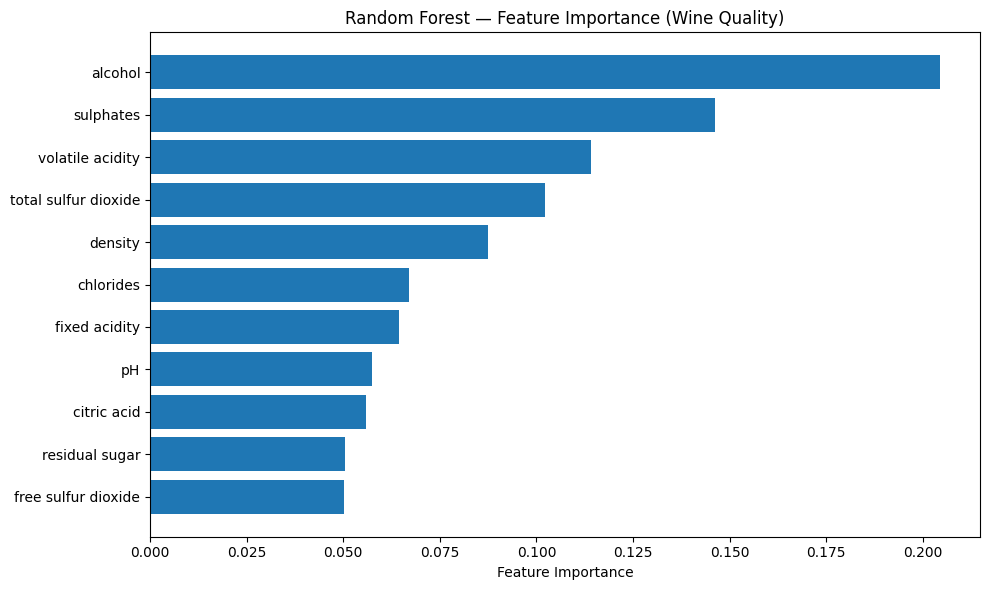

In [18]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest — Feature Importance (Wine Quality)')
plt.tight_layout()
plt.show()


### Boosting: Learning from Mistakes

While bagging builds models in parallel, **boosting** builds them **sequentially**. Each new model focuses on correcting the errors of the previous models. It's like a student who reviews their mistakes after each test and focuses specifically on the topics they got wrong.

### AdaBoost (Adaptive Boosting)

AdaBoost was one of the first successful boosting algorithms. Its approach is elegant:

1. Train a simple model (often a "stump" — a Decision Tree with depth 1)
2. Look at which samples it got wrong
3. **Increase the weight** of misclassified samples so the next model pays more attention to them
4. Train the next model on the reweighted data
5. Repeat, then combine all models with weights based on their accuracy


In [20]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")


AdaBoost Accuracy: 0.7344


The `learning_rate` controls how much each model contributes to the final prediction. Lower values require more estimators but often lead to better generalization.

### Gradient Boosting

Gradient Boosting takes the boosting idea further by framing it as an optimization problem. Instead of reweighting samples, it fits each new model to the **residual errors** (the difference between predictions and actual values) of the combined ensemble so far. It's literally doing gradient descent in function space.


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")


Gradient Boosting Accuracy: 0.8187


Key parameters for Gradient Boosting:
- `n_estimators`: Number of boosting rounds
- `max_depth`: Depth of each tree (usually 3-8; deeper trees = more complex)
- `learning_rate`: Step size — smaller values need more estimators but generalize better
- `subsample`: Fraction of data used per tree (< 1.0 adds stochastic element)

The interplay between `learning_rate` and `n_estimators` is important: lower learning rate + more estimators = slower training but often better results.

Let's visualize how the training and validation performance evolve with more boosting rounds:


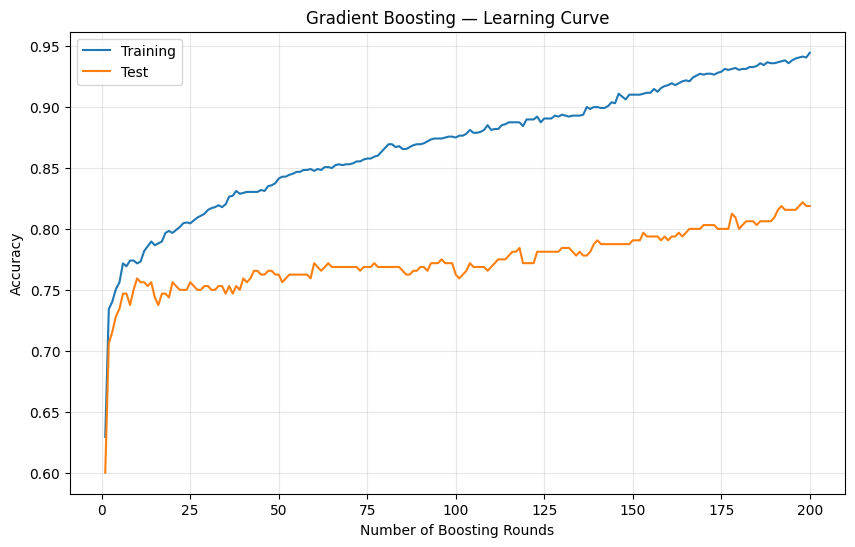

In [22]:
from sklearn.metrics import log_loss

train_scores = []
test_scores = []

for i, y_pred_train in enumerate(gb.staged_predict(X_train)):
    train_scores.append(accuracy_score(y_train, y_pred_train))

for i, y_pred_test in enumerate(gb.staged_predict(X_test)):
    test_scores.append(accuracy_score(y_test, y_pred_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_scores) + 1), train_scores, label='Training')
plt.plot(range(1, len(test_scores) + 1), test_scores, label='Test')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting — Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### XGBoost and LightGBM (Conceptual Overview)

In practice, data scientists often use optimized implementations of gradient boosting:

- **XGBoost** (Extreme Gradient Boosting): Adds regularization terms and uses a more efficient algorithm. It became famous for dominating Kaggle competitions.
- **LightGBM**: Uses histogram-based splitting and leaf-wise growth for even faster training, especially on large datasets.

Both are external libraries (not part of scikit-learn's core), but they follow the same scikit-learn API pattern:


In [24]:
!pip install xgboost lightgbm

In [25]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [26]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=200, max_depth=3, learning_rate=0.1)
lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 684, number of negative: 595
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000212 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 1279, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.534793 -> initscore=0.139397
[LightGBM] [Info] Start training from score 0.139397
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


If you're working on a real project and need maximum performance, XGBoost and LightGBM are worth exploring.

## Stacking: The Meta-Learner Approach

**Stacking** (Stacked Generalization) takes a fundamentally different approach from bagging and boosting. Instead of combining models through voting or sequential learning, it trains a **meta-learner** that learns how to best combine the predictions of base models.

### How Stacking Works

1. Train several diverse base models (e.g., Logistic Regression, SVM, Random Forest)
2. Each base model makes predictions on the training data (using cross-validation to avoid data leakage)
3. Use these predictions as **new features** for a meta-model
4. The meta-model learns which base models to trust in which situations


### Implementation


In [27]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=10000),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_scaled, y_train)

y_pred_stack = stacking.predict(X_test_scaled)
print(f"Stacking Classifier Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")


Stacking Classifier Accuracy: 0.7500


The `cv=5` parameter tells scikit-learn to use 5-fold cross-validation when generating base model predictions for the meta-learner. This prevents the meta-learner from overfitting to the base models' training predictions.

The strength of stacking lies in **model diversity** — the base models should be as different as possible (different algorithms, different hyperparameters) so they capture different aspects of the data.

## Voting: Hard vs. Soft

**Voting** is the simplest way to combine multiple models. You train several classifiers and combine their predictions through a vote.

### Hard Voting

Each model gets one vote. The class with the most votes wins:


In [29]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('lr', LogisticRegression(max_iter=10000, random_state=42))
    ],
    voting='hard',
    n_jobs=-1
)
voting_hard.fit(X_train_scaled, y_train)

y_pred_hard = voting_hard.predict(X_test_scaled)
print(f"Hard Voting Accuracy: {accuracy_score(y_test, y_pred_hard):.4f}")


Hard Voting Accuracy: 0.7875


### Soft Voting

Instead of counting votes, soft voting averages the **predicted probabilities** across all models and picks the class with the highest average probability. This is generally better because it takes into account how confident each model is:


In [30]:
voting_soft = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('lr', LogisticRegression(max_iter=10000, random_state=42))
    ],
    voting='soft',
    n_jobs=-1
)
voting_soft.fit(X_train_scaled, y_train)

y_pred_soft = voting_soft.predict(X_test_scaled)
print(f"Soft Voting Accuracy: {accuracy_score(y_test, y_pred_soft):.4f}")


Soft Voting Accuracy: 0.7812


Soft voting usually outperforms hard voting because a model that predicts 95% probability for a class carries more weight than one that barely predicts 51%.

## Comparing All Ensemble Methods

Let's bring everything together and see how all our ensemble methods stack up:


In [25]:
all_models = {
    'Baseline (Single Tree)': y_pred_baseline,
    'Bagging': y_pred_bagging,
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_ada,
    'Gradient Boosting': y_pred_gb,
    'Stacking': y_pred_stack,
    'Hard Voting': y_pred_hard,
    'Soft Voting': y_pred_soft,
}

results = []
for name, y_pred in all_models.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (weighted)': float(classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'])
    })

comparison = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("Ensemble Methods Comparison:")
print(comparison.to_string(index=False))


Ensemble Methods Comparison:
                 Model  Accuracy  F1 (weighted)
     Gradient Boosting  0.818750       0.818949
         Random Forest  0.803125       0.803081
           Hard Voting  0.787500       0.787733
           Soft Voting  0.781250       0.781456
               Bagging  0.753125       0.753330
              Stacking  0.750000       0.750293
              AdaBoost  0.734375       0.734689
Baseline (Single Tree)  0.731250       0.731440


## When to Use Which Ensemble

Choosing the right ensemble method depends on your situation. Here's a practical guide:

| Method | Best For | Pros | Cons |
|--------|----------|------|------|
| **Bagging** | High-variance models (deep trees) | Reduces variance, parallelizable | Doesn't help with biased models |
| **Random Forest** | General-purpose, feature importance | Robust, few hyperparameters | Less interpretable than single tree |
| **AdaBoost** | Simple base models, moderate data | Good with weak learners | Sensitive to outliers and noise |
| **Gradient Boosting** | Maximum accuracy, structured data | Often best performance | Slow to train, many hyperparameters |
| **Stacking** | Diverse model combination | Leverages model strengths | Complex, risk of overfitting |
| **Voting** | Quick combination of existing models | Simple to implement | Only as good as individual models |

**Rules of thumb:**
1. **Start with Random Forest** — it's hard to beat for a first ensemble
2. **Try Gradient Boosting** when you need maximum performance and have time to tune
3. **Use Stacking** when you have very different models that each excel in different areas
4. **Use Voting** when you already have several trained models and want a quick boost

## Summary

Congratulations — you've just mastered the art of combining models! Here's what you've learned:

- **Ensemble methods** combine multiple models to achieve better performance than any single model alone
- **Bagging** (Bootstrap Aggregating) trains models on random data subsets and reduces variance through averaging
- **Random Forests** extend bagging with feature randomization and provide out-of-bag error estimation
- **AdaBoost** sequentially trains models, increasing focus on previously misclassified samples
- **Gradient Boosting** fits new models to residual errors, performing gradient descent in function space
- **XGBoost and LightGBM** are optimized gradient boosting libraries that dominate competitions
- **Stacking** trains a meta-learner on base model predictions, learning how to best combine them
- **Voting** combines predictions through majority vote (hard) or probability averaging (soft)
- The choice between methods depends on your data, time constraints, and performance goals

This wraps up Unit 4.1 on Machine Learning fundamentals! You've gone from understanding what ML is, through building regression and classification models, to combining models with ensemble methods. In Unit 4.2, you'll explore more advanced topics like dimensionality reduction, clustering, and model evaluation strategies.

Head to the lab to build your own ensemble models and see these techniques in action!
